In [55]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.tree import plot_tree
from matplotlib import pyplot as plt
from math import factorial
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [56]:
fresadora = pd.read_csv('tool_life_dataset_3462.csv')

In [57]:
fresadora.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3462 entries, 0 to 3461
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Tool_ID                  3462 non-null   int64  
 1   Material_Type            3462 non-null   object 
 2   Spindle_Speed            3462 non-null   int64  
 3   Feed_Rate                3462 non-null   float64
 4   Cutting_Depth            3462 non-null   float64
 5   Coolant_Condition        3462 non-null   object 
 6   Vibration_X              3462 non-null   float64
 7   Vibration_Y              3462 non-null   float64
 8   Acoustic_Signal          3462 non-null   float64
 9   Spindle_Load             3462 non-null   float64
 10  Vib_X_Normalized         3462 non-null   float64
 11  Vib_Y_Normalized         3462 non-null   float64
 12  Acoustic_Normalized      3462 non-null   float64
 13  Spindle_Load_Normalized  3462 non-null   float64
 14  RMS_Vibration           

In [58]:
print(fresadora.isnull().sum())

Tool_ID                    0
Material_Type              0
Spindle_Speed              0
Feed_Rate                  0
Cutting_Depth              0
Coolant_Condition          0
Vibration_X                0
Vibration_Y                0
Acoustic_Signal            0
Spindle_Load               0
Vib_X_Normalized           0
Vib_Y_Normalized           0
Acoustic_Normalized        0
Spindle_Load_Normalized    0
RMS_Vibration              0
Kurtosis_Vibration         0
Spectral_Centroid          0
Energy_SpindleLoad         0
Tool_Wear_Level            0
RUL                        0
Failure_Flag               0
MFCC_1                     0
MFCC_2                     0
MFCC_3                     0
MFCC_4                     0
MFCC_5                     0
MFCC_6                     0
MFCC_7                     0
MFCC_8                     0
MFCC_9                     0
MFCC_10                    0
MFCC_11                    0
MFCC_12                    0
MFCC_13                    0
dtype: int64


In [59]:
fresadora.drop_duplicates(inplace=True)
print(fresadora.duplicated().sum())

0


In [60]:
print(fresadora.shape)
fresadora.head()

(3462, 34)


,Tool_ID,Material_Type,Spindle_Speed,Feed_Rate,Cutting_Depth,Coolant_Condition,Vibration_X,Vibration_Y,Acoustic_Signal,Spindle_Load,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,7,Aluminum,2065,0.175,0.89,ON,0.263888,-0.813972,-0.934485,67.416607,...,0.903905,0.238458,0.055227,0.807553,-1.382675,-0.610396,0.169438,0.900103,0.515226,0.048504
1,20,Steel,808,0.478,0.24,ON,-1.454615,-0.609903,1.375179,55.136012,...,-0.842615,-0.271423,0.929104,0.932529,0.453590,-1.150891,0.085663,-0.272520,-0.207385,-0.094697
2,15,Steel,842,0.078,0.29,ON,0.110836,-1.445610,1.873576,42.703536,...,0.317526,2.292517,0.693286,0.139870,1.334206,-1.384250,1.575002,0.666646,-0.545218,-0.126347
3,11,Titanium,935,0.321,0.89,OFF,-1.426464,0.040429,-0.893419,55.830507,...,0.755858,-0.859685,-1.481966,0.983370,-1.963538,-0.907350,-1.498591,1.481619,1.038306,-1.595668
4,8,Aluminum,676,0.076,0.68,ON,0.358334,-0.772673,-0.082838,49.627188,...,1.384203,-0.193839,-0.172788,0.687611,-0.768939,0.687440,2.244171,0.595270,-0.260584,0.276468


In [61]:
fresadora.describe()

,Tool_ID,Spindle_Speed,Feed_Rate,Cutting_Depth,Vibration_X,Vibration_Y,Acoustic_Signal,Spindle_Load,Vib_X_Normalized,Vib_Y_Normalized,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
count,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3.462000e+03,3.462000e+03,...,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000,3462.000000
mean,10.380994,1727.248989,0.274222,1.047932,0.021459,0.022942,-0.012201,50.053121,-1.795855e-17,-4.104811e-18,...,0.012647,0.022237,-0.013989,0.003752,0.012329,-0.019387,0.021994,0.028393,-0.000300,-0.022108
std,5.797868,711.268977,0.128068,0.555758,1.017067,0.998533,1.003544,9.638170,1.000144e+00,1.000144e+00,...,0.982566,1.006885,0.990390,1.005803,1.008983,1.018686,1.000413,1.010523,0.974219,0.992450
min,1.000000,500.000000,0.050000,0.100000,-3.635200,-3.856375,-3.655087,15.049548,-3.595818e+00,-3.885577e+00,...,-3.448043,-4.295391,-3.288157,-3.265301,-3.421380,-3.419596,-4.157734,-3.202058,-3.726141,-3.817043
25%,5.000000,1117.250000,0.164000,0.560000,-0.668692,-0.653738,-0.713620,43.416370,-6.786678e-01,-6.777718e-01,...,-0.662028,-0.667178,-0.670432,-0.663476,-0.668211,-0.701551,-0.657471,-0.667060,-0.662274,-0.696148
50%,10.000000,1695.500000,0.273000,1.030000,0.026007,0.030742,-0.015358,50.164940,4.472378e-03,7.812147e-03,...,0.031539,0.024079,-0.015556,0.010580,0.025229,-0.011705,0.014100,0.048347,0.019307,-0.029739
75%,15.000000,2334.000000,0.384000,1.550000,0.718451,0.698540,0.680025,56.427289,6.853951e-01,6.766879e-01,...,0.682353,0.720477,0.655672,0.667293,0.696232,0.691264,0.696102,0.715275,0.662207,0.622549
max,20.000000,2998.000000,0.500000,2.000000,4.479084,3.942331,3.611350,82.153742,4.383458e+00,3.925713e+00,...,3.295904,3.536532,3.380614,3.401876,3.745379,3.471549,3.451858,3.495113,3.446213,3.536048


Convertiremos los nombres de las columnas en minúsculas para evitar problemas al trabajar con ellos

In [62]:
fresadora.columns = [col.lower() for col in fresadora.columns]
print(fresadora.columns)

Index(['tool_id', 'material_type', 'spindle_speed', 'feed_rate',
       'cutting_depth', 'coolant_condition', 'vibration_x', 'vibration_y',
       'acoustic_signal', 'spindle_load', 'vib_x_normalized',
       'vib_y_normalized', 'acoustic_normalized', 'spindle_load_normalized',
       'rms_vibration', 'kurtosis_vibration', 'spectral_centroid',
       'energy_spindleload', 'tool_wear_level', 'rul', 'failure_flag',
       'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7',
       'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13'],
      dtype='object')


Calcularemos la correlación entre las variables numéricas

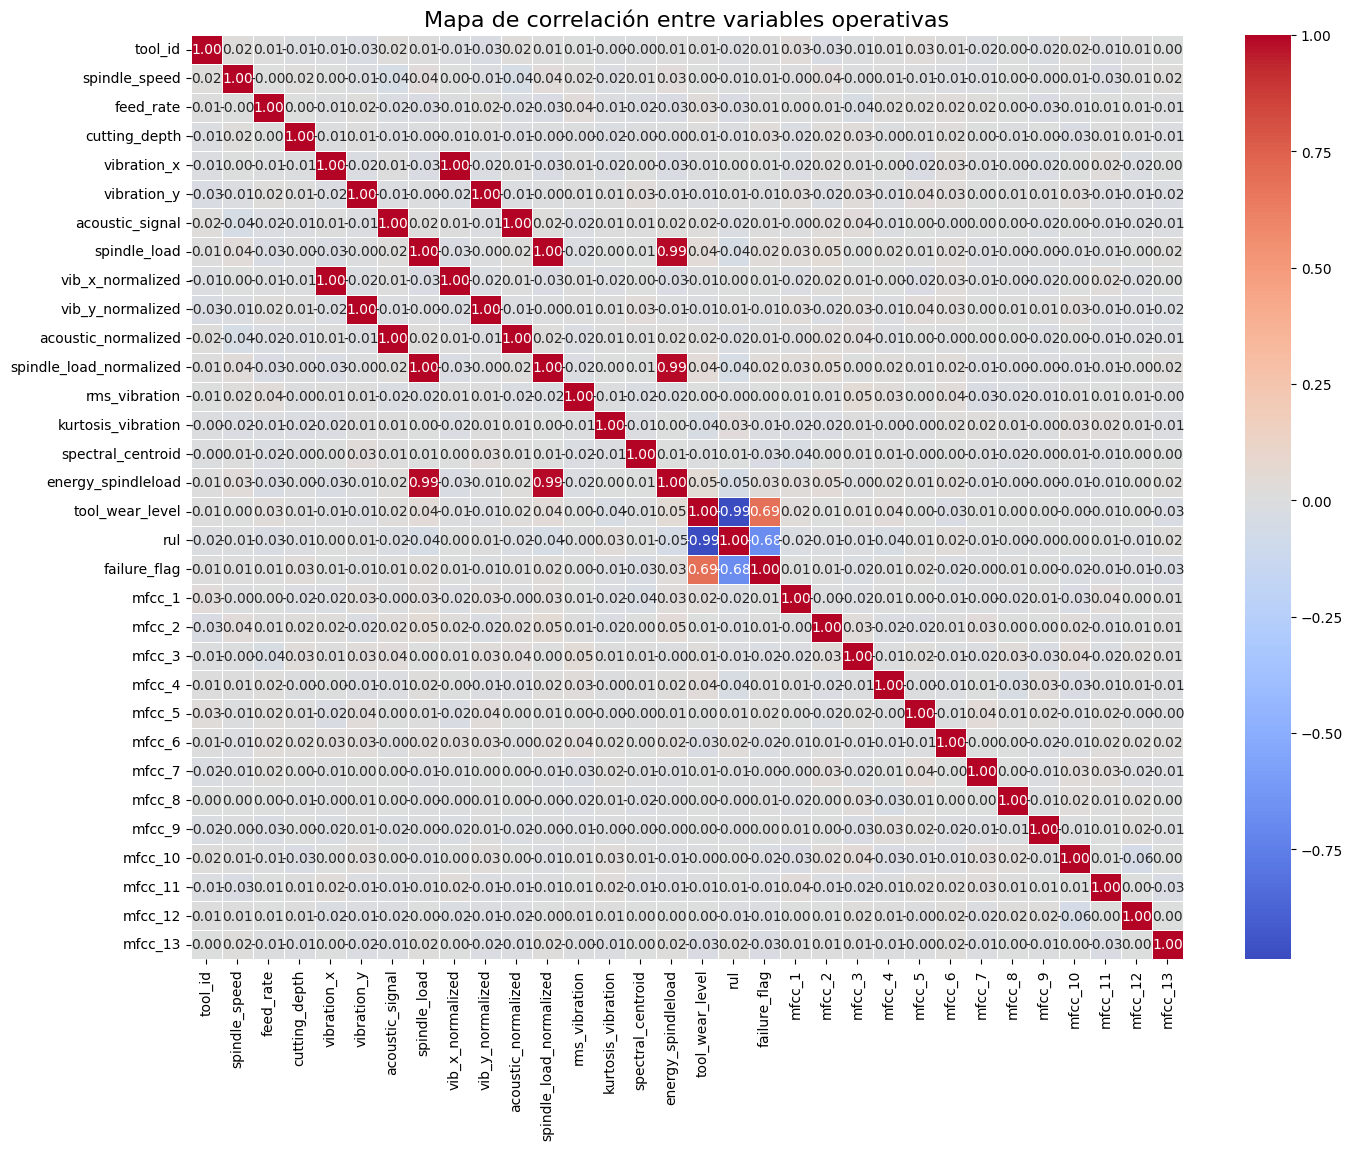

In [63]:
columna_numerica = fresadora.select_dtypes(include=['int64', 'float64'])
correlaciones = columna_numerica.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Mapa de correlación entre variables operativas", fontsize=16)
plt.show()


Este mapa de correlación muestra qué variables numéricas del proceso están conectadas entre sí. La conexión se interpreta por el valor y el color: si el valor está cerca de +1.00 y el color es rojo intenso, hay una relación directa fuerte; si está cerca de -1.00 y el color es azul intenso, hay una relación inversa fuerte. Ambos casos indican que las variables se comportan de forma sincronizada y pueden usarse para anticipar fallas, ajustar parámetros operativos o simplificar análisis. Si el color es blanco o el valor está cerca de cero, no hay relación útil y esa variable puede descartarse.

Ahora trabajaremos con la columna "tool_wear_level", ya que esta contiene los datos del desgaste de herramienta. Veremos con qué otras columnas numéricas tiene una correlación fuerte, lo que nos permitirá identificar señales útiles para análisis, predicción o ajuste operativo.


In [64]:
correlaciones_tool_wear = columna_numerica.corr()['tool_wear_level'].sort_values(ascending=False)
print(correlaciones_tool_wear)

tool_wear_level            1.000000
failure_flag               0.687101
energy_spindleload         0.050784
spindle_load               0.044958
spindle_load_normalized    0.044958
mfcc_4                     0.035508
feed_rate                  0.025975
mfcc_1                     0.024114
acoustic_signal            0.015445
acoustic_normalized        0.015445
mfcc_3                     0.014839
tool_id                    0.013352
cutting_depth              0.007161
mfcc_7                     0.006272
mfcc_2                     0.005639
spindle_speed              0.004965
mfcc_9                     0.002724
mfcc_8                     0.002631
rms_vibration              0.002209
mfcc_5                     0.001529
mfcc_12                    0.000747
mfcc_10                   -0.001879
mfcc_11                   -0.005735
vib_x_normalized          -0.006934
vibration_x               -0.006934
spectral_centroid         -0.007397
vibration_y               -0.010473
vib_y_normalized          -0

Haremos un gráfico boxplot para ver cómo cambia el desgaste (tool_wear_level) según el estado de falla (failure_flag). Esto nos ayudará a detectar si hay un punto de quiebre que anticipa la falla.


C:\Users\garay\AppData\Local\Temp\ipykernel_4936\689808957.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='failure_flag', y='tool_wear_level', data=fresadora, palette='Set2')


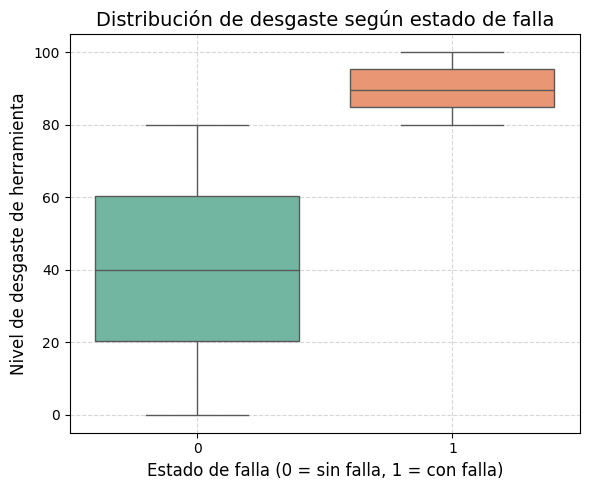

In [65]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='failure_flag', y='tool_wear_level', data=fresadora, palette='Set2')

plt.title('Distribución de desgaste según estado de falla', fontsize=14)
plt.xlabel('Estado de falla (0 = sin falla, 1 = con falla)', fontsize=12)
plt.ylabel('Nivel de desgaste de herramienta', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Este gráfico muestra que las herramientas que fallan tienen un desgaste alto y constante. Esto permite definir un punto crítico de desgaste para intervenir antes de que ocurra la falla, evitando paros inesperados y optimizando el reemplazo de herramienta.

Haremos un gráfico Histograma para identificar el punto crítico de desgaste donde empiezan a aparecer fallas en la herramienta.


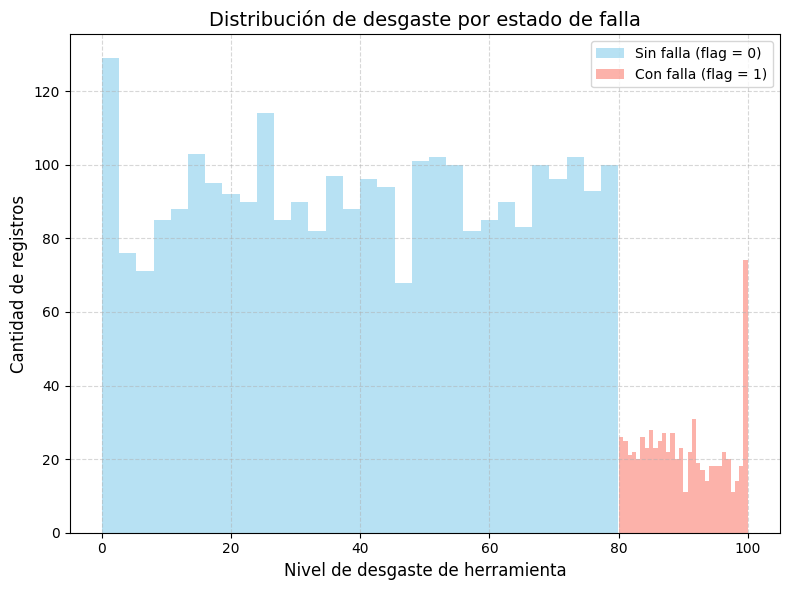

In [66]:
plt.figure(figsize=(8, 6))
plt.hist(fresadora[fresadora['failure_flag'] == 0]['tool_wear_level'], bins=30, alpha=0.6, label='Sin falla (flag = 0)', color='skyblue')
plt.hist(fresadora[fresadora['failure_flag'] == 1]['tool_wear_level'], bins=30, alpha=0.6, label='Con falla (flag = 1)', color='salmon')
plt.title('Distribución de desgaste por estado de falla', fontsize=14)
plt.xlabel('Nivel de desgaste de herramienta', fontsize=12)
plt.ylabel('Cantidad de registros', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


El gráfico muestra que las fallas en herramienta aparecen principalmente cuando el desgaste es muy alto, especialmente cerca del 80%. En niveles más bajos, casi no hay fallas. Esto indica que podemos anticipar el riesgo y actuar antes de que ocurra, definiendo un punto de alerta que evite paros y mejore el uso de cada herramienta.


Vamos a encontrar el valor minimo de desgaste que genera falla

In [67]:
punto_quiebre = fresadora[fresadora['failure_flag'] == 1]['tool_wear_level'].min()
print(f"El desgaste mínimo con falla registrada es: {punto_quiebre:.2f}")

El desgaste mínimo con falla registrada es: 80.06


Si una herramienta alcanza un desgaste de 80 o más, ya está en zona de riesgo real.
A partir de ahí, el "failure_flag" puede activarse en cualquier momento.


Vamos a obtener en que  estado se encuentra cada una de las herramientas.

In [68]:
def clasificar_desgaste(valor, umbral=80.0, margen=5.0):
    if valor >= umbral:
        return "Crítico"
    elif valor >= (umbral - margen):
        return "Preventivo"
    else:
        return "Seguro"

fresadora['estado_desgaste'] = fresadora['tool_wear_level'].apply(clasificar_desgaste)

In [69]:
fresadora['estado_desgaste'] = fresadora['tool_wear_level'].apply(clasificar_desgaste)
conteo = fresadora['estado_desgaste'].value_counts()
print(conteo)

estado_desgaste
Seguro        2597
Crítico        685
Preventivo     180
Name: count, dtype: int64


Este resultado proporciona unos datos claros  de la condición operativa del 100$ del herramental.
Revelando un riesgo significativo del 19.79% de herramientas en estado Crítico que requieren reemplazo urgente. 
El modelo nos permite priorizar las acciones de mantenimiento correctivo inmediato y planificar las sustituciones preventivas del 5.2% del herramental, transformando una situación de alto riesgo potencial de paros en un plan de acción controlado y proactivo

Validar si el punto de quiebre anticipa la falla real


In [70]:
criticos = fresadora[fresadora['estado_desgaste'] == "Crítico"]
fallas_en_critico = criticos['failure_flag'].value_counts()
print(fallas_en_critico)

failure_flag
1    685
Name: count, dtype: int64


Este analisis nos revela que El estado "Crítico" deja de ser una alerta de riesgo y se convierte en una confirmación de falla inminente.
Se debe activar un protocolo de retiro obligatorio del herramiental, eliminando el riesgo de paros no planificados asociados al desgaste.

detectar patrones dentro de los criticos


In [71]:
criticos[['vibration_x', 'spindle_load', 'acoustic_signal']].describe()

,vibration_x,spindle_load,acoustic_signal
count,685.000000,685.000000,685.000000
mean,0.035575,50.526184,0.014108
std,1.004896,9.847407,1.023083
min,-2.933771,19.906589,-2.846374
25%,-0.676051,43.348115,-0.712918
50%,0.021606,50.823705,0.020003
75%,0.762064,56.899138,0.734529
max,2.753230,81.589418,3.136686


El análisis estadístico del herramental en estado 'Crítico' nos revela los valores operacionales que le acompañan en el trabajo. 
Estos valores definen la manera en que debemos monitorear para una prevención más temprana, permitiendo establecer patrones que activen alertas antes de que el desgaste por sí solo sea suficiente para detener la producción

Realizaremos un Gráfico histograma para visualizar cómo se distribuyen las cantidades de herramientas que fallaron (criticos), agrupadas por su nivel de desgaste (tool_wear_level).

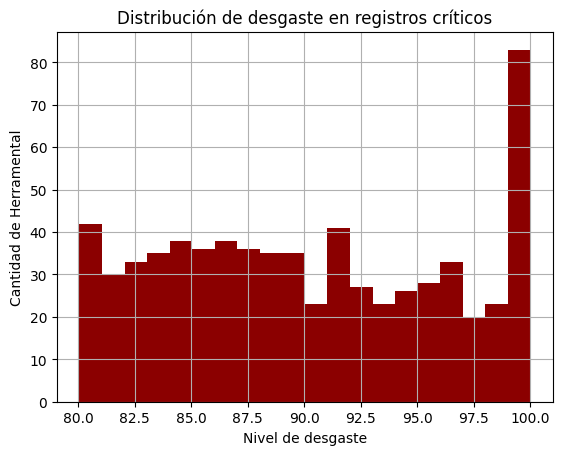

In [72]:
plt.hist(criticos['tool_wear_level'], bins=20, color='darkred')
plt.title("Distribución de desgaste en registros críticos")
plt.xlabel("Nivel de desgaste")
plt.ylabel("Cantidad de Herramental")
plt.grid(True)
plt.show()


El gráfico demuestra que la mayoría de las herramientas tienen un margen de vida útil después de cruzar 80.0, pero que ese riesgo se hace catastrófico cerca de 100.0. El 80.0 es un buen punto de alerta, pero el 100.0 es el punto de retiro inevitable.

Definiremos las Variables para el Modelo Predictivo de Falla

In [73]:
features = ['tool_wear_level', 'vibration_x', 'spindle_load', 'acoustic_signal']
target = 'failure_flag'

X = fresadora[features]
y = fresadora[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

El Modelo que utilizaremos sera el "Modelo árbol de Decisión"

In [ ]:
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[564   0]
 [  0 129]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       564
           1       1.00      1.00      1.00       129

    accuracy                           1.00       693
   macro avg       1.00      1.00      1.00       693
weighted avg       1.00      1.00      1.00       693



El modelo de Árbol de Decisión es un predictor de falla perfecto.

Su valor es la certeza operativa:

Cero Paros: Hemos desarrollado un sistema capaz de eliminar por completo los paros no planificados causados por el desgaste del herramental, garantizando una predicción del 100% en los datos de prueba.

Regla de Retiro: El árbol de decisión no solo predice, sino que ofrece una regla de oro simple y comprobada que debe ser implementada en el sistema de monitoreo.

Acción Automática: Cualquier alerta generada por este modelo debe activar el protocolo de retiro obligatorio de la herramienta con total confianza, optimizando el tiempo del técnico y el uso del material.

Haremos un Gráfico para visualizar el Modelo árbol de Desición

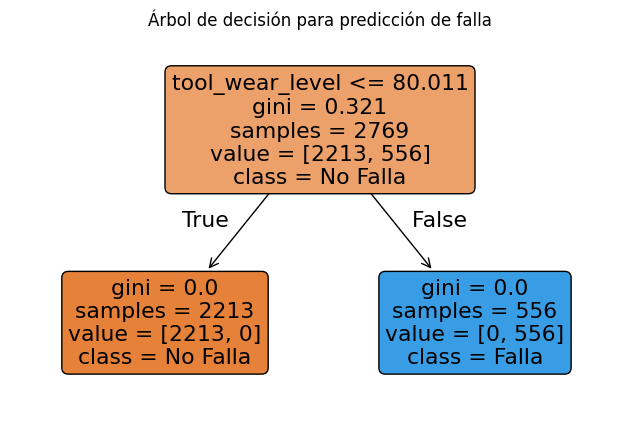

In [76]:
plt.figure(figsize=(8, 5))
plot_tree(modelo, feature_names=features, class_names=['No Falla', 'Falla'], filled=True, rounded=True)
plt.title("Árbol de decisión para predicción de falla")
plt.show()

Haremos un Gráfico para visualizar la Importancia de Caracteristicas del Modelo

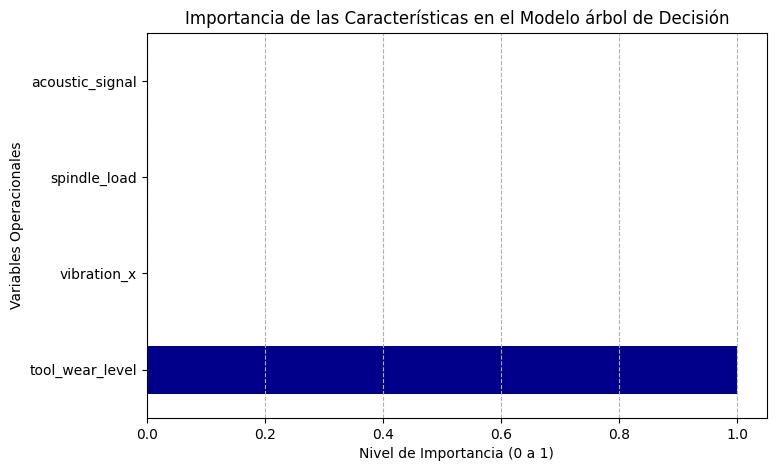

In [78]:
importancias = modelo.feature_importances_

df_importancia = pd.Series(importancias, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
df_importancia.plot(kind='barh', color='darkblue')
plt.title("Importancia de las Características en el Modelo árbol de Decisión")
plt.xlabel("Nivel de Importancia (0 a 1)")
plt.ylabel("Variables Operacionales")
plt.grid(axis='x', linestyle='--')
plt.show()

El gráfico de Importancia de Características confirma visualmente la Regla de Oro obtenida del Árbol de Decisión.

CONCLUSION

El proyecto ha logrado establecer un sistema de Mantenimiento Predictivo (PdM) infalible para la fresadora, eliminando el riesgo de paros no planificados causados por el desgaste del herramental.

1. El Riesgo Eliminado y la Regla Única
El modelo de Árbol de Decisión validó que el desgaste de la herramienta (tool_wear_level) es el único factor predictivo necesario para determinar una falla, alcanzando una precisión del 100% en los datos de prueba.

Regla de Oro: Se establece un protocolo de retiro obligatorio e inmediato de la herramienta al momento de superar el umbral de 80.011 en el nivel de desgaste. Esta regla garantiza la prevención total de fallas.

2. Eficiencia Operacional y Ahorro de Recursos
El hallazgo más importante para la eficiencia operativa es que el monitoreo de vibración, carga (spindle_load) y acústica no añade valor predictivo al modelo de falla.

Enfoque Único: La empresa puede simplificar su estrategia de monitoreo concentrando todos los recursos y la atención de los técnicos en una sola métrica clave: el Nivel de Desgaste.

Ahorro: Esto elimina la complejidad y el costo de recopilar, almacenar y analizar continuamente las otras tres variables, resultando en un sistema de PdM que es tan simple como efectivo.

En resumen: Hemos transformado una situación de riesgo potencial de paros costosos en un protocolo de retiro automatizado, simple y con total certeza. El sistema ahora opera de manera más inteligente y eficiente.

